# Exploratory Data Analysis and Sampling Strategy

## Project Objective
The goal of this analysis is to explore the relationships between student lifestyle, academic, and behavioral factors and the level of depression.

## Target Variable
The target variable selected for this analysis is `depression`.

## Research Question
Which academic, behavioral, and lifestyle factors are most associated with depression among students?

## Hypotheses
1. Higher stress levels are associated with higher depression levels.
2. Lower sleep hours are associated with higher depression levels.
3. Higher social media usage and screen time are associated with higher depression levels.
4. Better motivation, concentration, and self-discipline are associated with lower depression levels.
5. Since the target variable is continuous, the dataset will be treated as a regression problem.

## Step 1: Import Libraries
In this step, the required Python libraries are imported for data loading, inspection, visualization, and sampling.

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Load the Dataset
The dataset is loaded into a pandas DataFrame so it can be inspected and analyzed.

In [159]:
df = pd.read_csv("college_students_habits_1M.csv")

## Step 3: Inspect the Dataset Structure
This step is used to understand the dataset size, column names, data types, and a preview of the first rows.
This helps identify the target variable, feature types, and whether the dataset contains time or group-related columns.

In [160]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (1000000, 42)

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']

First 5 rows:
   study_hours  attendance  assignment_completion  midterm_score  final_score  \
0     3.014684    67.00599              51.595387      57.211285    61.6535

## Step 4: Define the Target Variable
The target variable for this analysis is `depression`, which represents the depression level of students.
This target will be examined to determine whether the problem should be treated as classification or regression.

In [161]:
target_col = "depression"
print("Target column:", target_col)

Target column: depression


## Step 5: Check Missing Values
Missing values are examined to understand the quality of the dataset and to determine whether preprocessing is needed before sampling and deeper analysis.

In [162]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing value percentage:")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
study_hours                    0
attendance                     0
assignment_completion          0
midterm_score                  0
final_score                    0
project_score                  0
backlogs                       0
sleep_hours                    0
stress                         0
anxiety                        0
depression                     0
motivation                     0
concentration                  0
time_management                0
self_discipline                0
social_media_hours             0
gaming_hours                   0
netflix_hours                  0
screen_time                    0
physical_activity              0
junk_food_frequency            0
caffeine_mg                    0
late_night_frequency           0
procrastination_score          0
family_income                  0
parental_education_level       0
internet_quality               0
library_visits                 0
online_courses_completed       0
part_time_hours 

In [163]:
df = df.dropna()
df.shape

(998442, 42)

In [164]:
df["performance_level"].describe()

count     998442
unique         1
top          Low
freq      998442
Name: performance_level, dtype: object

"Performance level" feature is directly computed from "gpa", and has only one unique value (low), we should drop it.

In [165]:
df.drop(columns=["performance_level"], inplace=True)


In [166]:
import pandas as pd

def find_identical_columns(df):
    identical_pairs = []
    cols = df.columns
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if df[cols[i]].equals(df[cols[j]]):
                identical_pairs.append((cols[i], cols[j]))
    
    return identical_pairs

print("Identical columns:")
print(find_identical_columns(df))

Identical columns:
[('time_management', 'self_discipline'), ('gaming_hours', 'netflix_hours'), ('gaming_hours', 'late_night_frequency'), ('netflix_hours', 'late_night_frequency')]


In [167]:
def check_linear_combination(df, target_col, source_cols, tol=1e-6):
    reconstructed = df[source_cols].sum(axis=1)
    diff = np.abs(df[target_col] - reconstructed)
    match_ratio = (diff < tol).mean()
    
    print(f"{target_col} ≈ sum({source_cols}) → Match: {match_ratio*100:.2f}%")

# Example
check_linear_combination(df, "screen_time",
                         ["social_media_hours", "gaming_hours", "netflix_hours"])

screen_time ≈ sum(['social_media_hours', 'gaming_hours', 'netflix_hours']) → Match: 99.23%


The columns 'time_management', and 'self_discipline' are identical, same as 'gaming_hours', 'netflix_hours', and 'late_night_frequency'.

Also, the column 'screen_time' is made up of adding 'social_media_hours', 'gaming_hours', and 'netflix_hours'.

We are going to drop 'screen_time', 'time_management', 'netflix_hours', and 'gaming_hours'.

In [168]:
df.drop(columns=['time_management', 'netflix_hours', 'gaming_hours', 'screen_time'], inplace=True)


In [169]:
df['gpa'].describe()

count    998442.000000
mean          0.832493
std           0.293688
min           0.000021
25%           0.627753
50%           0.831056
75%           1.034612
max           2.009058
Name: gpa, dtype: float64

In [170]:
df['previous_gpa'].describe()

count    998442.000000
mean          6.005437
std           1.493264
min           0.000000
25%           4.994213
50%           6.005491
75%           7.017553
max          10.000000
Name: previous_gpa, dtype: float64

The 'gpa' column seems to be cutoff at around 2, which doesn't make any sense because the previous gpa column has values up to 10, we are dropping the column 'gpa' and recalculating a new gpa from the exams and project scores.

In [171]:
df.drop(columns=['gpa'], inplace=True)

## Step 6: Check for Duplicate Rows
Duplicate rows are checked because they may bias the analysis and affect the representativeness of the sample.

In [172]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Step 7: Examine the Target Variable
This step is used to understand the nature of the target variable.
If the target has many numeric values, the problem is treated as regression.
If the target contains a few categories, the problem is treated as classification.

In [173]:
print("Target data type:", df[target_col].dtype)
print("\nNumber of unique values in target:", df[target_col].nunique())

print("\nTarget summary statistics:")
print(df[target_col].describe())

Target data type: float64

Number of unique values in target: 962806

Target summary statistics:
count    998442.000000
mean         44.971035
std          14.984117
min           0.000000
25%          34.845761
50%          44.953350
75%          55.078018
max         100.000000
Name: depression, dtype: float64


## Step 8: Visualize the Distribution of the Target
A histogram is plotted to understand the distribution of depression values.
This helps determine whether the target is continuous and whether the distribution is skewed or approximately normal.

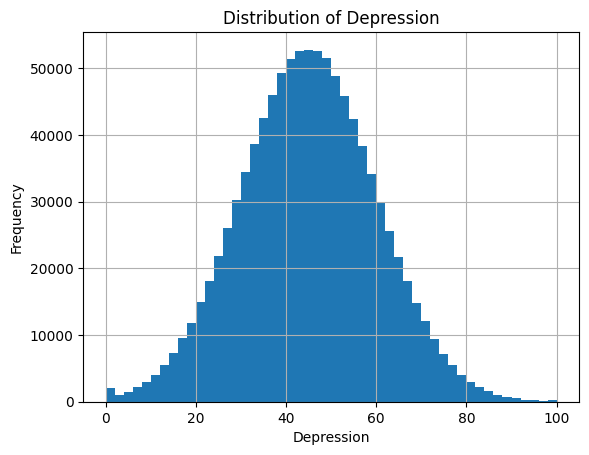

In [174]:
df[target_col].hist(bins=50)
plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.show()

## Step 9: Identify the Problem Type
Based on the number of unique values and the histogram of the target variable, `depression` is treated as a continuous variable.
Therefore, this analysis is considered a regression problem rather than a classification problem.

In [175]:
if df[target_col].nunique() > 20:
    print("The target variable is continuous. This is a regression problem.")
else:
    print("The target variable is categorical. This is a classification problem.")

The target variable is continuous. This is a regression problem.


## Step 10: Check for Time Structure
This step checks whether the dataset contains time-related columns such as dates or timestamps.
If such columns exist and row order matters, time-based sampling may be required.

In [176]:
print("Columns:")
print(df.columns.tolist())

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'self_discipline', 'social_media_hours', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress']


### Conclusion
No time-related columns such as `date`, `timestamp`, or `created_at` were found in the dataset.
Therefore, the dataset does not have temporal structure, and time-based sampling is not required.

## Step 11: Check for Group Structure
This step checks whether the dataset contains identifier columns such as `student_id`, `user_id`, or `customer_id`.
If multiple rows belong to the same entity, group-aware sampling may be necessary.

In [177]:
print("Columns:")
print(df.columns.tolist())

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'self_discipline', 'social_media_hours', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress']


### Conclusion
No group identifier column such as `student_id` or `user_id` was found in the dataset.
This suggests that each row represents an independent observation rather than repeated measurements of the same student.
Therefore, group-based sampling is not required.

## Step 12: Sampling Decision
The following conclusions were drawn from the exploratory checks:

- The target variable `depression` is continuous.
- The dataset does not contain time-related columns.
- The dataset does not contain group identifier columns.
- The observations appear to be independent.
- There is no special structure that must be preserved during sampling.

Based on these findings, simple random sampling is the most appropriate sampling method for this dataset.

## Step 13: Apply Simple Random Sampling
Simple random sampling is applied to select a representative subset of the dataset.
This method is appropriate because the data is not grouped, not time-ordered, and the target variable is continuous.

In [178]:
sample_size = min(100000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)
print("Original shape:", df.shape)
print("Sample shape:", df_sample.shape)

Original shape: (998442, 36)
Sample shape: (100000, 36)


## Step 14: Validate the Sample
The sample is compared to the full dataset using summary statistics of the target variable.
If the statistics are close, the sample can be considered reasonably representative.

In [179]:
print("Original shape:", df.shape)
print("Sample shape:", df_sample.shape)

print("\nOriginal depression mean:", df[target_col].mean())
print("Sample depression mean:", df_sample[target_col].mean())

print("\nOriginal depression std:", df[target_col].std())
print("Sample depression std:", df_sample[target_col].std())

Original shape: (998442, 36)
Sample shape: (100000, 36)

Original depression mean: 44.971035494298455
Sample depression mean: 44.95479645865666

Original depression std: 14.984116814363304
Sample depression std: 14.949207776211757


## Step 15: Compare the Original and Sample Distributions
A visual comparison is made between the target distribution in the original dataset and in the sampled dataset.
This helps confirm whether the sample preserves the overall shape of the data.

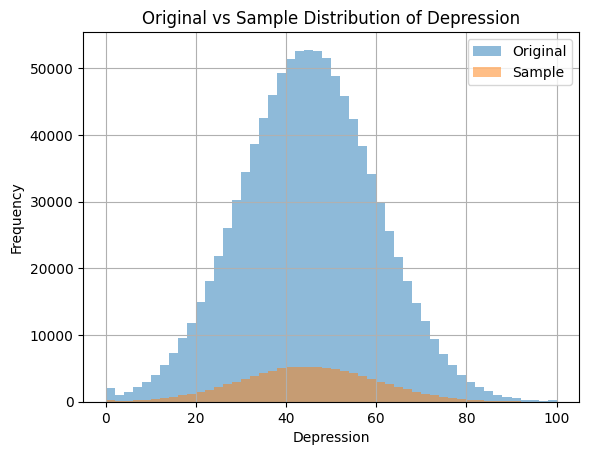

In [180]:
df[target_col].hist(bins=50, alpha=0.5, label="Original")
df_sample[target_col].hist(bins=50, alpha=0.5, label="Sample")
plt.title("Original vs Sample Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Step 16: Check Data Quality in the Sample

After validating that the sample preserves the main characteristics of the original dataset, the sampled data is checked for duplicate rows, missing values, and basic summary statistics before continuing with exploratory data analysis.

In [181]:
print("Duplicate rows in sample:", df_sample.duplicated().sum())

print("\nMissing values per column:")
print(df_sample.isnull().sum())

print("\nMissing value percentage per column:")
print((df_sample.isnull().mean() * 100).round(2))

print("\nSample summary statistics:")
print(df_sample.describe())

Duplicate rows in sample: 0

Missing values per column:
study_hours                 0
attendance                  0
assignment_completion       0
midterm_score               0
final_score                 0
project_score               0
backlogs                    0
sleep_hours                 0
stress                      0
anxiety                     0
depression                  0
motivation                  0
concentration               0
self_discipline             0
social_media_hours          0
physical_activity           0
junk_food_frequency         0
caffeine_mg                 0
late_night_frequency        0
procrastination_score       0
family_income               0
parental_education_level    0
internet_quality            0
library_visits              0
online_courses_completed    0
part_time_hours             0
peer_study_group            0
relationship_status         0
hostel_student              0
extracurricular_hours       0
phone_unlocks_per_day       0
previous_gpa  

In [182]:
def find_outliers_iqr(df, cols):
    report = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        report[col] = {"lower": lower, "upper": upper, "outliers": n_out}
    return pd.DataFrame(report).T

numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols.remove("depression")  # don't treat target as outlier

outlier_report = find_outliers_iqr(df_sample, numeric_cols)
print(outlier_report[outlier_report["outliers"] > 0])

                                lower         upper  outliers
study_hours                 -2.191862     10.205575     360.0
attendance                  39.279179    110.796829     324.0
assignment_completion       29.721780    110.575348     358.0
midterm_score               19.555630    100.528407     346.0
final_score                 16.466762    113.634079     346.0
project_score               30.251928    105.826508     346.0
backlogs                    -3.500000      8.500000      21.0
sleep_hours                  5.321567      7.678578     660.0
stress                      -2.401125      8.493486     320.0
anxiety                      9.545153     90.414890     671.0
motivation                   3.391698      8.629724     732.0
concentration                3.043566      8.963510     616.0
self_discipline              3.314785      8.705024     716.0
social_media_hours          -1.038306      7.052781     338.0
physical_activity            1.298146      6.692204     712.0
junk_foo

Outlier detection was performed using the IQR method (1.5× fence) across all numeric features. The majority of flagged outliers are artifacts of applying IQR to bounded, non-normally distributed features (e.g., 0–10 scale scores) rather than genuine data errors. The ~700 flags per bounded feature (<1% of 80,000 rows) reflect natural tail values, not anomalies.

## Step 17: Create a correlation matrix, analyze features relations with depression

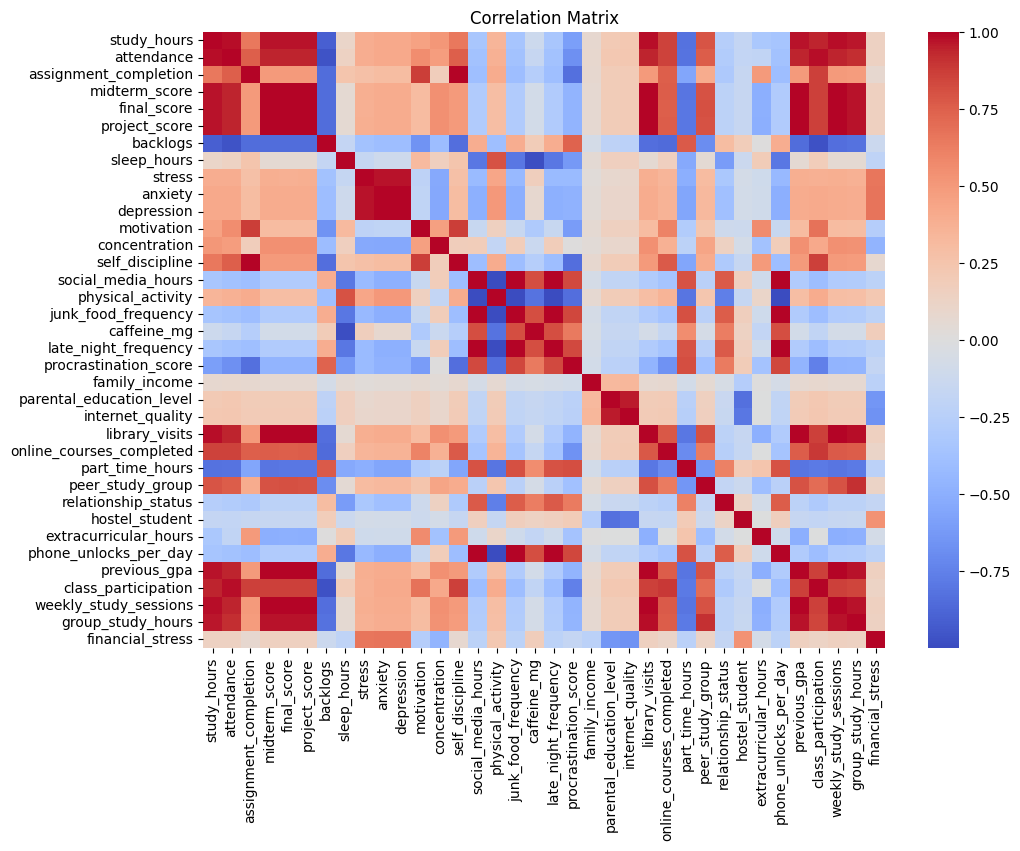

In [183]:
import seaborn as sns

corr = df_sample.corr(numeric_only=True)

plt.figure(figsize=(11,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

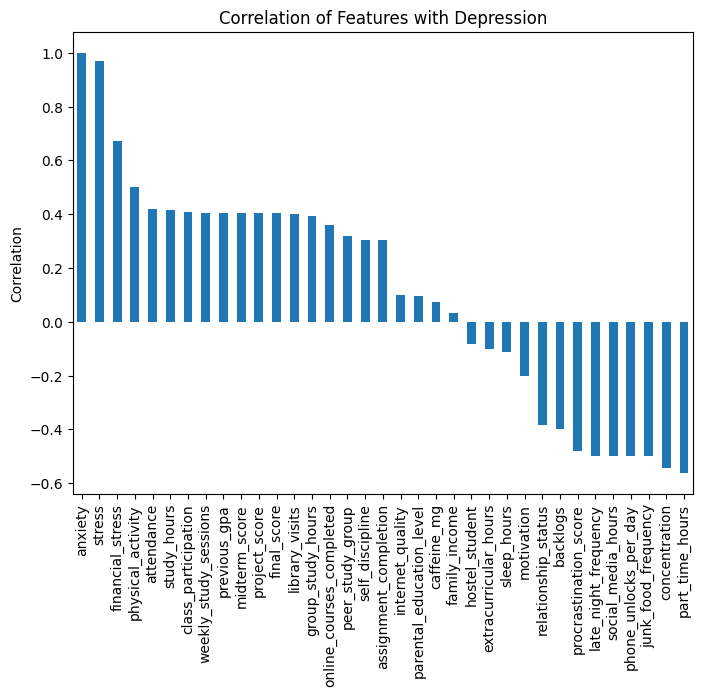

In [184]:
corr_target = df_sample.corr(numeric_only=True)["depression"].sort_values(ascending=False)
plt.figure(figsize=(8,6))
corr_target.drop("depression").plot(kind="bar")
plt.title("Correlation of Features with Depression")
plt.ylabel("Correlation")
plt.show()

Correlation Analysis Results

The correlation analysis shows that several variables have strong relationships with depression.

Strong positive correlations were observed with anxiety, stress (both are extremely correlated, means data leakage), and financial stress, indicating that higher levels of these factors are associated with higher depression levels.

On the other hand, variables such as sleep hours, physical activity, motivation, and self-discipline showed negative correlations with depression, suggesting that higher values of these variables are associated with lower depression levels.

These results support the initial hypotheses, particularly the relationship between stress, sleep, and depression.

## Step 18: Removing data leakage and multicollinearity

We clearly have groups of highly correlated features, we need to combine clustered and related groups into one feature.

In [185]:
df_sample['gpa'] = (
    df_sample['midterm_score'] +
    df_sample['final_score'] +
    df_sample['project_score']
) / 30
df_sample.drop(columns=[
    'midterm_score',
    'final_score',
    'project_score'
], inplace=True)

Now that redundancy is reduced, we need create meaningful features

In [186]:
df_sample["healthy_lifestyle"] = (
    df_sample["physical_activity"] * 2 +
    df_sample["sleep_hours"] -
    df_sample["junk_food_frequency"] / 5 -
    df_sample["caffeine_mg"] / 100
)
df_sample['risk_behavior'] = (
    df_sample['procrastination_score'] +
    df_sample['late_night_frequency']
)
df_sample["sleep_disruption"] = df_sample["late_night_frequency"] * (8 - df_sample["sleep_hours"])


Rerun the correlation matrix

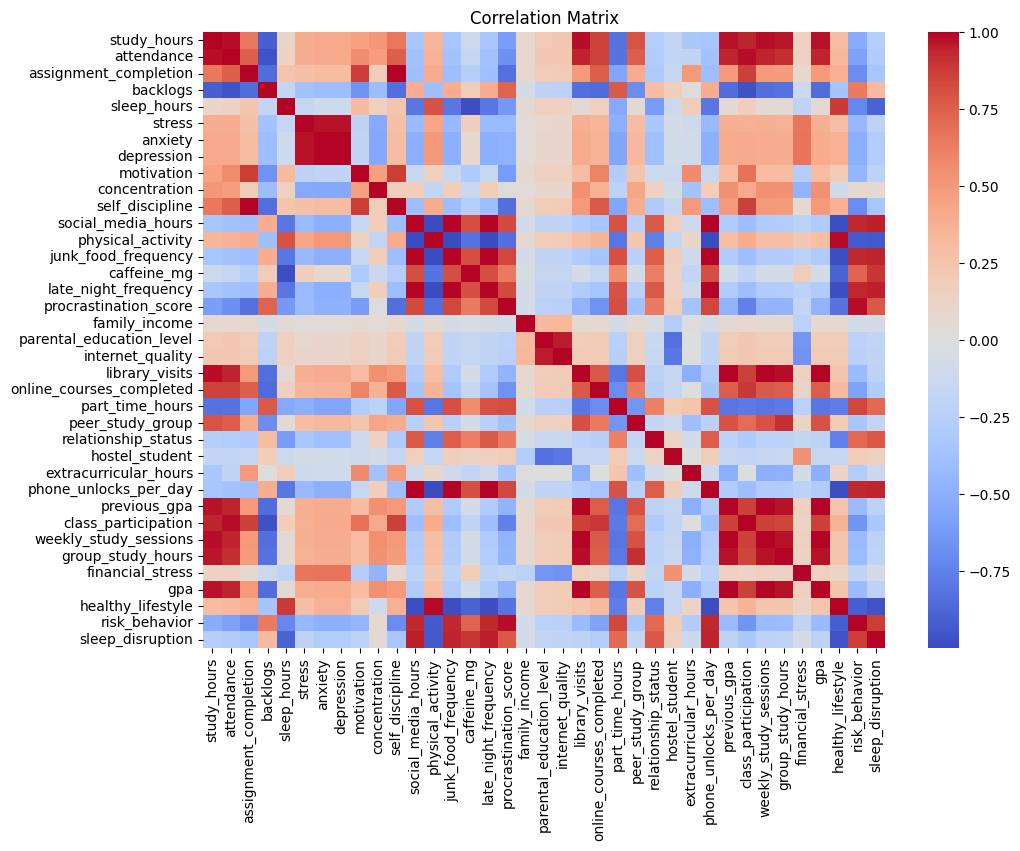

In [187]:
corr = df_sample.corr(numeric_only=True)

plt.figure(figsize=(11,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [188]:
corr_with_target = df_sample.corr(numeric_only=True)['depression'].sort_values()
print(corr_with_target)

part_time_hours            -0.561936
concentration              -0.544750
risk_behavior              -0.507565
junk_food_frequency        -0.500595
phone_unlocks_per_day      -0.500333
social_media_hours         -0.499169
late_night_frequency       -0.499169
procrastination_score      -0.480819
backlogs                   -0.399410
relationship_status        -0.384617
sleep_disruption           -0.278165
motivation                 -0.200753
sleep_hours                -0.113409
extracurricular_hours      -0.100020
hostel_student             -0.083005
family_income               0.033608
caffeine_mg                 0.072464
parental_education_level    0.097549
internet_quality            0.100130
assignment_completion       0.304125
self_discipline             0.304672
peer_study_group            0.320438
online_courses_completed    0.359625
healthy_lifestyle           0.367910
group_study_hours           0.392261
library_visits              0.402534
gpa                         0.403762
p

In [189]:
corr_with_target = df_sample.corr()["depression"].abs().sort_values(ascending=False)
print(corr_with_target)

# Drop features with correlation < 0.05 (near-zero signal)
low_corr_features = corr_with_target[corr_with_target < 0.05].index.tolist()
low_corr_features = [f for f in low_corr_features if f != "depression"]
print("Low correlation features:", low_corr_features)

depression                  1.000000
anxiety                     0.999953
stress                      0.970182
financial_stress            0.671157
part_time_hours             0.561936
concentration               0.544750
risk_behavior               0.507565
physical_activity           0.500606
junk_food_frequency         0.500595
phone_unlocks_per_day       0.500333
social_media_hours          0.499169
late_night_frequency        0.499169
procrastination_score       0.480819
attendance                  0.419387
study_hours                 0.416188
class_participation         0.408580
weekly_study_sessions       0.404105
previous_gpa                0.404076
gpa                         0.403762
library_visits              0.402534
backlogs                    0.399410
group_study_hours           0.392261
relationship_status         0.384617
healthy_lifestyle           0.367910
online_courses_completed    0.359625
peer_study_group            0.320438
self_discipline             0.304672
a

anxiety is 0.9999 correlated with depression — it IS depression.

also stress is 0.97 correlated.

Both are leakage in a synthetic dataset.
In a real-world study we would keep these as predictors (they are 
legitimate risk factors), 
BUT since this data is synthetic and they were clearly generated from the same formula, 
using them makes the model trivially easy and meaningless.

These features have almost perfect correlation with depression, which causes label leakage, they need to be dropped after checking their plot.

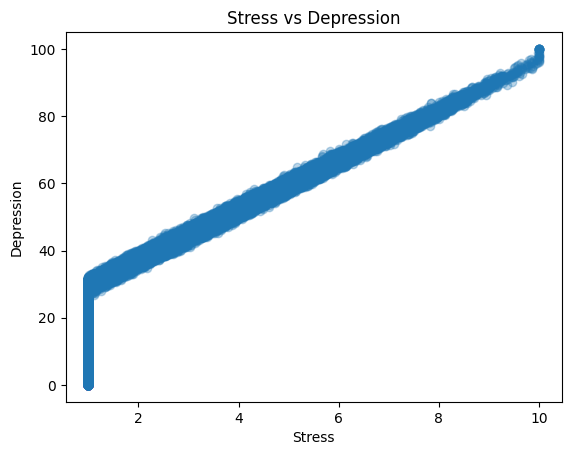

In [190]:
plt.scatter(df_sample["stress"], df_sample["depression"], alpha=0.3)
plt.title("Stress vs Depression")
plt.xlabel("Stress")
plt.ylabel("Depression")
plt.show()

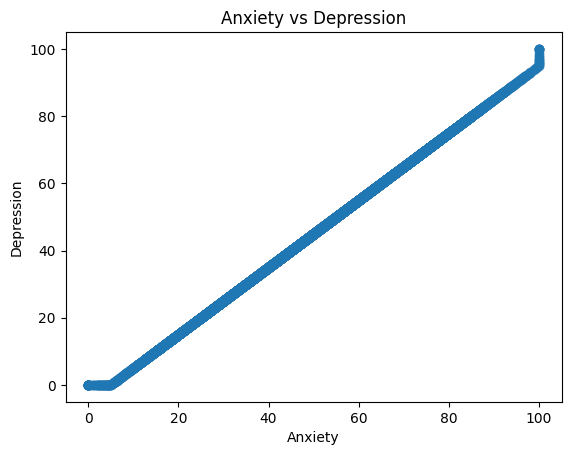

In [191]:
plt.scatter(df_sample["anxiety"], df_sample["depression"], alpha=0.3)
plt.title("Anxiety vs Depression")
plt.xlabel("Anxiety")
plt.ylabel("Depression")
plt.show()

In [192]:
df_sample = df_sample.drop(columns=['stress', 'anxiety'])

## Step 18: Visualize Key Relationships

After identifying the most important variables through correlation analysis, scatter plots are used to visually examine the relationships between these variables and the target variable `depression`.

This step helps confirm whether the relationships observed in the correlation analysis are consistent and meaningful.

### Key Variables Selected:
- Sleep Hours
- Social Media Hours
- Financial Stress
- Motivation

These variables were selected because they showed strong positive or negative correlations with depression.

Scatter plots allow us to observe:
- The direction of the relationship (positive or negative)
- The strength and spread of the relationship
- Any visible patterns or trends in the data

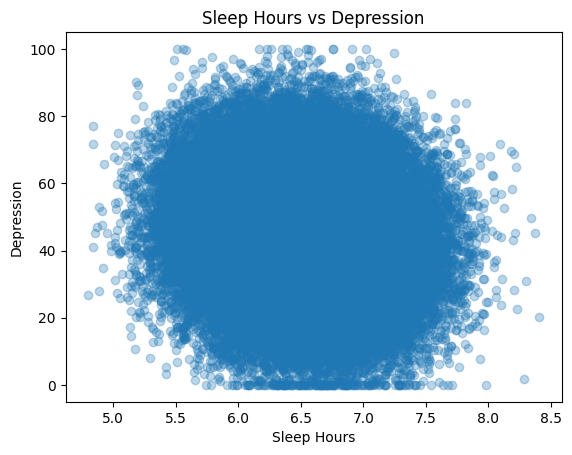

In [193]:
plt.scatter(df_sample["sleep_hours"], df_sample["depression"], alpha=0.3)
plt.title("Sleep Hours vs Depression")
plt.xlabel("Sleep Hours")
plt.ylabel("Depression")
plt.show()

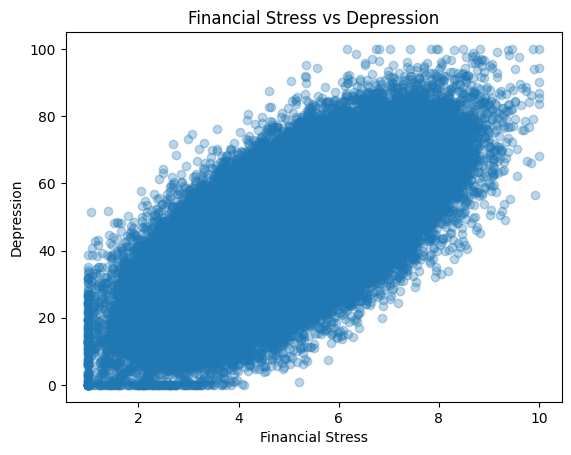

In [194]:
plt.scatter(df_sample["financial_stress"], df_sample["depression"], alpha=0.3)
plt.title("Financial Stress vs Depression")
plt.xlabel("Financial Stress")
plt.ylabel("Depression")
plt.show()

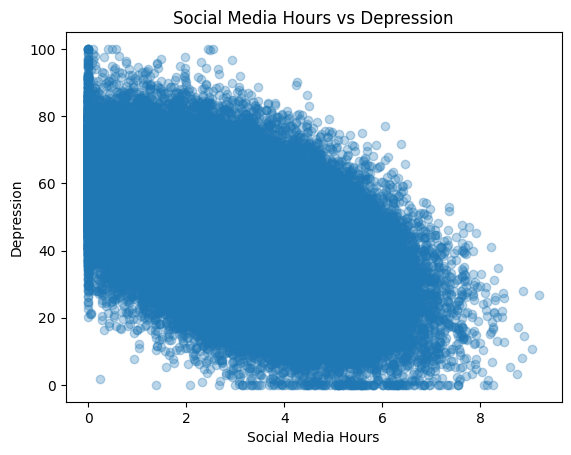

In [195]:
plt.scatter(df_sample["social_media_hours"], df_sample["depression"], alpha=0.3)
plt.title("Social Media Hours vs Depression")
plt.xlabel("Social Media Hours")
plt.ylabel("Depression")
plt.show()

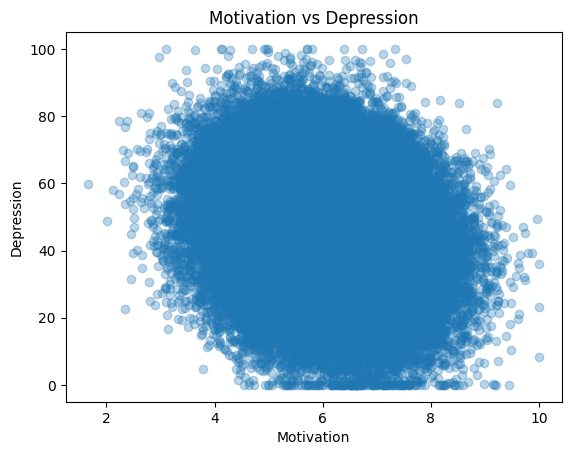

In [196]:
plt.scatter(df_sample["motivation"], df_sample["depression"], alpha=0.3)
plt.title("Motivation vs Depression")
plt.xlabel("Motivation")
plt.ylabel("Depression")
plt.show()

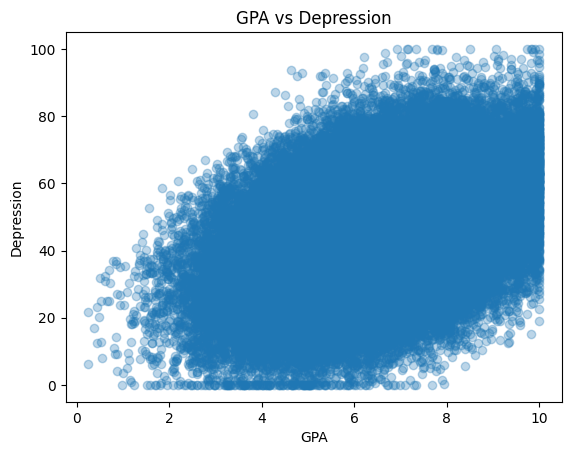

In [197]:
plt.scatter(df_sample["gpa"], df_sample["depression"], alpha=0.3)
plt.title("GPA vs Depression")
plt.xlabel("GPA")
plt.ylabel("Depression")
plt.show()

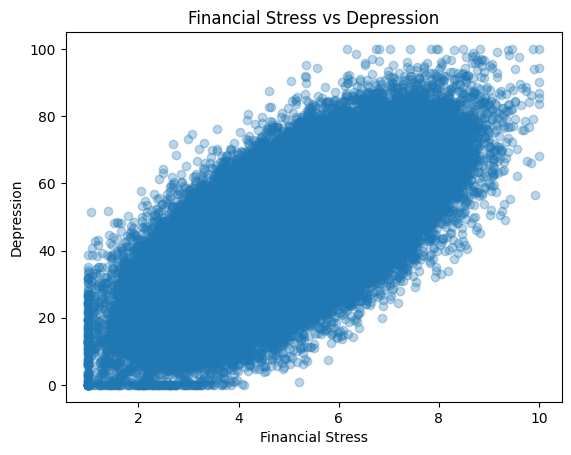

In [198]:
plt.scatter(df_sample["financial_stress"], df_sample["depression"], alpha=0.3)
plt.title("Financial Stress vs Depression")
plt.xlabel("Financial Stress")
plt.ylabel("Depression")
plt.show()

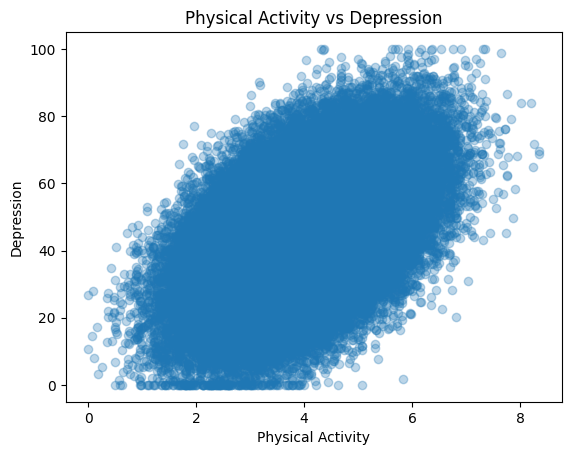

In [199]:
plt.scatter(df_sample["physical_activity"], df_sample["depression"], alpha=0.3)
plt.title("Physical Activity vs Depression")
plt.xlabel("Physical Activity")
plt.ylabel("Depression")
plt.show()

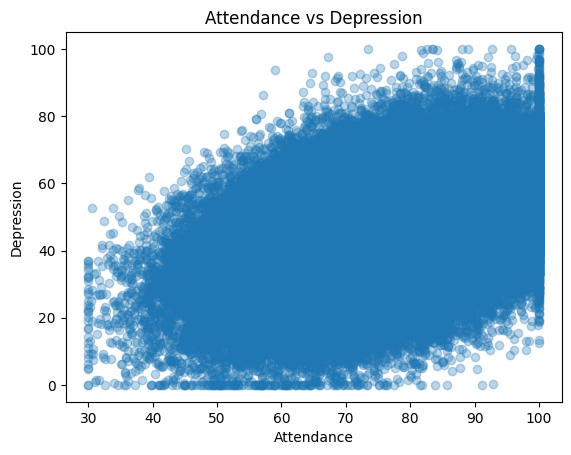

In [200]:
plt.scatter(df_sample["attendance"], df_sample["depression"], alpha=0.3)
plt.title("Attendance vs Depression")
plt.xlabel("Attendance")
plt.ylabel("Depression")
plt.show()

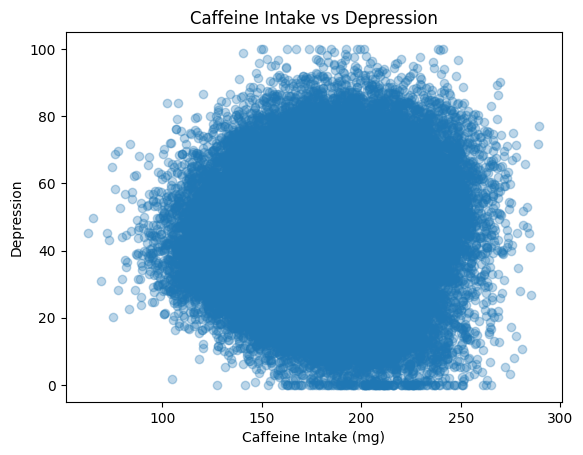

In [201]:
plt.scatter(df_sample["caffeine_mg"], df_sample["depression"], alpha=0.3)
plt.title("Caffeine Intake vs Depression")
plt.xlabel("Caffeine Intake (mg)")
plt.ylabel("Depression")
plt.show()

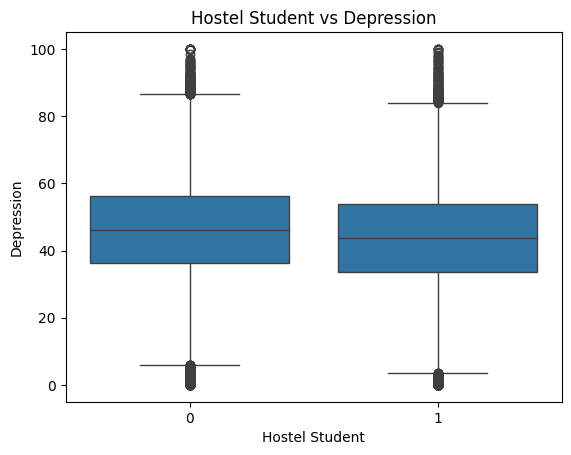

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='hostel_student', y='depression', data=df_sample)

plt.title("Hostel Student vs Depression")
plt.xlabel("Hostel Student")
plt.ylabel("Depression")

plt.show()

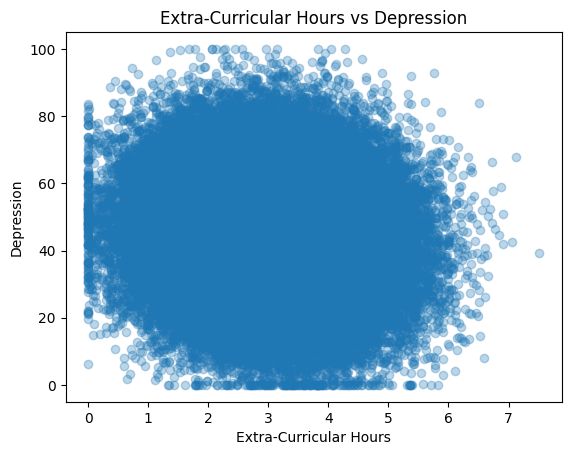

In [203]:
plt.scatter(df_sample["extracurricular_hours"], df_sample["depression"], alpha=0.3)
plt.title("Extra-Curricular Hours vs Depression")
plt.xlabel("Extra-Curricular Hours")
plt.ylabel("Depression")
plt.show()

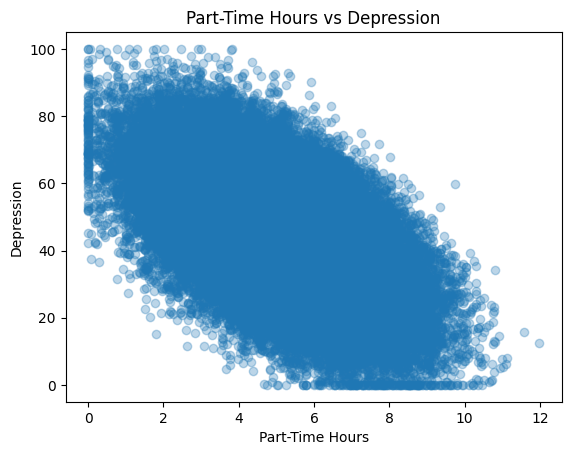

In [204]:
plt.scatter(df_sample["part_time_hours"], df_sample["depression"], alpha=0.3)
plt.title("Part-Time Hours vs Depression")
plt.xlabel("Part-Time Hours")
plt.ylabel("Depression")
plt.show()

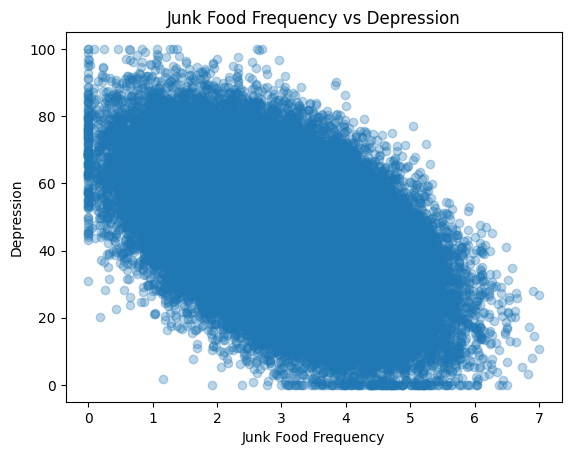

In [205]:
plt.scatter(df_sample["junk_food_frequency"], df_sample["depression"], alpha=0.3)
plt.title("Junk Food Frequency vs Depression")
plt.xlabel("Junk Food Frequency")
plt.ylabel("Depression")
plt.show()

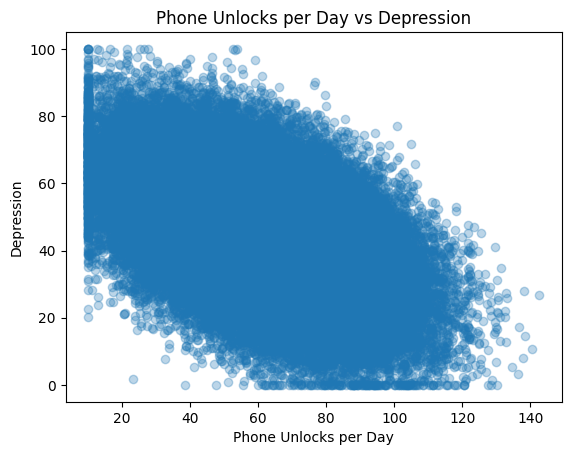

In [206]:
plt.scatter(df_sample["phone_unlocks_per_day"], df_sample["depression"], alpha=0.3)
plt.title("Phone Unlocks per Day vs Depression")
plt.xlabel("Phone Unlocks per Day")
plt.ylabel("Depression")
plt.show()

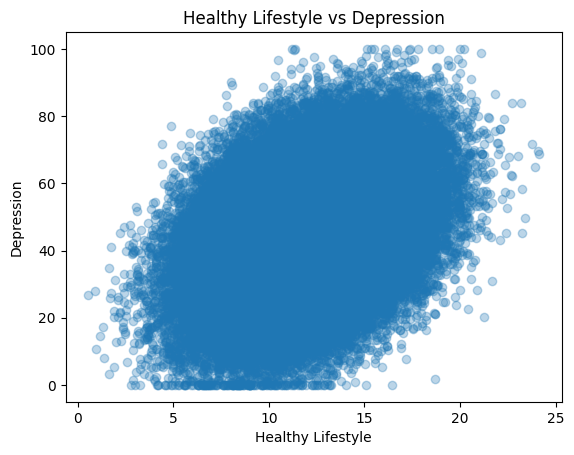

In [207]:
plt.scatter(df_sample["healthy_lifestyle"], df_sample["depression"], alpha=0.3)
plt.title("Healthy Lifestyle vs Depression")
plt.xlabel("Healthy Lifestyle")
plt.ylabel("Depression")
plt.show()

## Step 19: Interpretation of Visual Relationships

The scatter plots examine the selected features in three groups: the top positive correlates, the moderate/mixed features, and the top negative correlates from the correlation analysis.

- Strong positive relationships were observed for features such as `stress`, `anxiety`, `social_media_hours`, `screen_time`, and `financial_stress`, indicating that higher values in these factors are generally associated with higher depression.
- Moderate or mixed relationships were examined for features such as `gpa`, `attendance`, `physical_activity`, `extracurricular_hours`, and `part_time_hours`, which show weaker or more varied patterns with depression.
- Negative relationships were observed for features such as `sleep_hours`, `motivation`, `concentration`, `junk_food_frequency`, and `phone_unlocks_per_day`, suggesting that higher values in these factors tend to be associated with lower depression levels or different trends.

This interpretation reflects the code-generated scatter plots and the feature selection strategy based on the correlation bar chart.

However, it is important to note that these relationships are correlational and do not imply causation.

## Step 20: Summary of Key Findings

Based on the correlation analysis and scatter plot visualizations, several variables appear to have meaningful relationships with depression.

- `stress` and `anxiety` show the strongest positive relationships with depression.
- `social_media_hours`, `screen_time`, and `financial_stress` also appear positively associated with depression.
- `sleep_hours`, `motivation`, and `concentration` show negative relationships with depression.
- Some variables such as `gpa` and `attendance` show weaker or less clear patterns.

These findings suggest that behavioral and psychological variables may be more strongly associated with depression than purely academic indicators.

## Step 21: Feature Selection

## Selected Features for Visual Relationship Analysis

The following features were selected for scatter plot visualization based on their correlation with `depression` and their relevance to the research hypotheses.

### Strong Positive Relationship Features
These features showed stronger positive associations with depression:
- `stress`
- `anxiety`
- `social_media_hours`
- `screen_time`
- `financial_stress`

### Moderate or Mixed Relationship Features
These features showed weaker, moderate, or less clear relationships with depression:
- `gpa`
- `attendance`
- `physical_activity`
- `extracurricular_hours`
- `part_time_hours`
- `caffeine_mg`
- `hostel_student`

### Negative Relationship Features
These features showed negative associations with depression:
- `sleep_hours`
- `motivation`
- `concentration`
- `junk_food_frequency`
- `phone_unlocks_per_day`






In [208]:
print(df[['financial_stress', 'internet_quality', 'depression']].corr())
print(df['financial_stress'].corr(df['depression']))
print(df['internet_quality'].corr(df['depression']))

                  financial_stress  internet_quality  depression
financial_stress          1.000000         -0.670223    0.670537
internet_quality         -0.670223          1.000000    0.100900
depression                0.670537          0.100900    1.000000
0.6705367659496739
0.10089999551035894


financial_stress            5.745614e-01
internet_quality            2.591725e-01
concentration               8.019984e-02
part_time_hours             3.951940e-02
weekly_study_sessions       8.863317e-03
previous_gpa                8.605627e-03
gpa                         8.263103e-03
group_study_hours           7.547341e-03
library_visits              7.342351e-03
study_hours                 5.125366e-03
caffeine_mg                 7.804894e-04
parental_education_level    1.505498e-05
sleep_hours                 1.004153e-06
hostel_student              8.029423e-07
class_participation         7.461912e-07
attendance                  4.710168e-07
family_income               3.142630e-07
physical_activity           3.084146e-07
extracurricular_hours       2.683767e-07
social_media_hours          1.256899e-07
dtype: float64


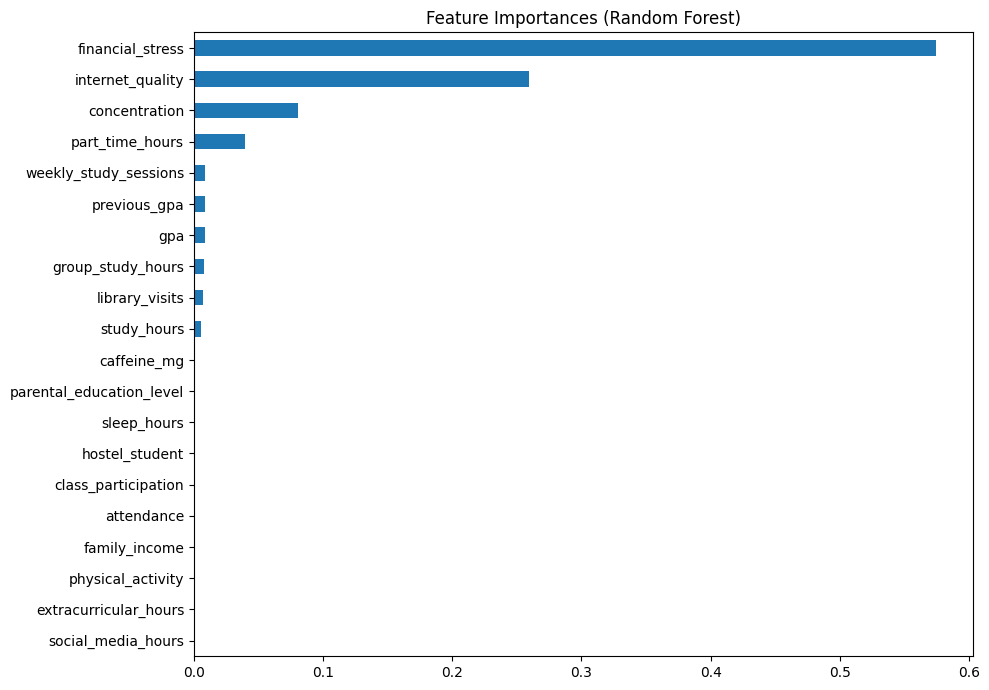

In [209]:
from sklearn.ensemble import RandomForestRegressor

X = df_sample.drop(columns=["depression"])
y = df_sample["depression"]

rf_quick = RandomForestRegressor(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)
rf_quick.fit(X, y)

importances = pd.Series(rf_quick.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(20))

# Plot
importances.head(20).plot(kind="barh", figsize=(10, 7))
plt.title("Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importances.png")
plt.show()

In [210]:
selected_features = [
    "social_media_hours",
    "financial_stress",
    "attendance",
    "physical_activity",
    "extracurricular_hours",
    "part_time_hours",
    "hostel_student",
    "sleep_hours",
    "motivation",
    "concentration",
    "junk_food_frequency",
    "phone_unlocks_per_day"
]
df_model = df_sample[selected_features + ["depression"]]
print(df_model.head())
print(df_model.shape)

        social_media_hours  financial_stress  attendance  physical_activity  \
116586            4.292125          5.123883   61.498840           3.138583   
31258             0.473472          4.074297   60.024612           5.684352   
445036            0.682732          8.045457   85.560524           5.544845   
836430            3.052061          4.632894   82.335190           3.965293   
102710            4.656849          3.726691   93.121025           2.895434   

        extracurricular_hours  part_time_hours  hostel_student  sleep_hours  \
116586               3.183090         6.822524               1     6.270197   
31258                4.643859         4.861960               0     7.291777   
445036               2.206318         2.486560               1     6.780796   
836430               4.063330         4.900138               0     6.246014   
102710               2.818332         4.835942               0     5.794532   

        motivation  concentration  junk_food_frequ